# Spatio-Temporal Forecasting of Elk and Pronghorn Wildlife-Vehicle Collisions (WVC) along Arizona Highway Corridors

**Name:** Great Gilbert Soco (26002404850)\
**Date:** 5/28/2026

# Spatio-Temporal Forecasting of Wildlife-Vehicle Collisions: A Multimodal Mixed-Model Approach for Arizona Highway Corridors

---

## 1. Research Foundation

### 1.1 Research Context & Motivation
In the statre of Arizona, transportation corridors, such as the Interstate 40 (I-40) and State Rout 260 (SR-260) cut directly through the native migratory ranges of animals, specifically elk and pronghorn. The result is a high frequency of safety-critical traffic incidents that cause significant property damage, ecological disruption, and human injuries and death. These incidents, known as Wildlife Vehicle Collisions (WVCs) represent a critical intersection between public safety, infrastructure resilience, and wildlife conservation.

Traditional approachs to transportation safety mapping relies heavily on past spatial density aggregation that focus more on static hotspot mapping of past WVCs rather than dynamic forecasting [1]. The nature of WVCs feature highly dynamic, temporal fluctations driven by various factors. These factors include human commuting cycles, changing seasonal conditions, and active wildlife migration waves. Traditional methods often fail to account for the highly dynamic nature of WVCs. To bridge this gap, this project reframes WVC mitigation as a dynamic spatio-temporal forecasting problem. By regularizing discrete accident logs into continuous spatial-temporal grids, this research aims to leverage deep learning architectures to predict localized risk horizons before collisions occur.

### 1.2 Research Question
To what extent can advanced machine learning architectures leverage a combination of historical accident sequences, seasonal human traffic variables, and exogenous biological tracking data to predict short-term Wildlife-Vehicle Collisions (WVC)? 

Specifically, how does a **univariate autoregressive model** (relying solely on historical crash logs to establish a performance baseline) compare against a **multivariate mixed-model fusion framework** that integrates the real-time migratory telemetry of elk and pronghorn across a distributed highway corridor network?

### 1.3 Methodological Scope & Modeling Paradigms
This study evaluates and benchmarks predictive performance across two distinct sections, explicitly differentiating between statistical scopes and spatial dimensions:

1. **Part 1: Univariate Autoregressive Modeling (The Baseline Floor)**
   * **Data Dimension:** Features are strictly limited to historical WVC event sequences and deterministic temporal vectors (cyclical calendar variations).
   * **Spatial Scope (Single-Point vs. Multi-Point):** This section contrasts traditional statistical forecasting with introductory deep learning. 
     * *Single-Point Scope:* Traditional models (Naïve, Moving Average, and Seasonal ARIMA) are trained on an isolated, high-density hazard segment (Segment 0) to evaluate local temporal patterns.
     * *Multi-Point Scope:* Baseline neural networks (Multi-Headed MLPs and 1D Convolutional Neural Networks) ingest the entire highway network simultaneously, assessing parallel spatial channels to identify broader trends across all 96 segments.
   * **Objective:** Establish a rigorous baseline performance floor to quantify how much predictive value can be extracted from historical crash trends alone.

2. **Part 2: Multivariate Mixed-Model Fusion (The Ecological Expansion)**
   * **Data Dimension:** Transitions from a pure time-series format to a multimodal mixed model. It fuses historical transportation records with real-time exogenous environmental features and spatialized USGS GPS-collar telemetry data tracking active ungulate migration waves.
   * **Spatial Scope (Multi-Point Network):** Full parallel channel processing across all 96 spatial corridors simultaneously.
   * **Objective:** Capture the non-linear, environmental catalysts of wildlife movement, transitioning the pipeline from a reactive historical log tracker into a proactive, ecologically grounded risk mitigation engine.

### 1.4 Engineering Justification
Modeling highway safety data presents a severe mathematical challenge: **extreme data sparsity**. Because accidents are safety-critical anomalies, the resulting daily matrix is highly zero-inflated (typically >95% zero values). Traditional statistical time-series models hit a structural ceiling here because they assume a continuous, linear Gaussian error distribution. 

By scaling to a multi-input, deep learning framework using **Long Short-Term Memory (LSTM)** networks, we introduce specialized memory gates capable of tracking temporal momentum across a lookback window. When fused with real-time biological telemetry vectors, the network can map ecological triggers directly onto specific spatial highway segments, bypassing the sparsity bottleneck and anticipating sudden crossing spikes.

### 1.5 Notebook Pipeline Architecture
To maintain maximum reproducibility and analytical clarity, the notebook is structured into the following operational phases:
* **Section 2: Exploratory Data Analysis & Spatial Matrix Engineering** – Aggregating point-event incident logs into a regularized daily 5-mile linear referencing matrix and quantifying global sparsity.
* **Section 3: Cyclical Feature Extraction** – Transforming calendar dates into non-linear temporal coordinates using sin/cos transformations.
* **Section 4: Part 1 - Univariate Benchmarking** – Implementing single-point statistical baselines (Naïve, MA, SARIMA) and multi-point baseline networks (MLP, 1D-CNN, Simple RNN).
* **Section 5: Part 2 - Multivariate Spatio-Temporal Fusion** – Processing USGS telemetry streams and training a multi-headed Ecological-Fusion LSTM.
* **Section 6: Applied Informatics & Infrastructure Synthesis** – Comparative performance tables, model validation analysis, and operational recommendations for dynamic highway warning deployments.

---

### Open-Source Project Repository
The complete source code, spatial shapefile layers, integrated preprocessing pipelines, and dynamic simulation assets for this research project are hosted publicly on GitHub. You can access the full operational environment here: **[GitHub Repository: WVC Simulation & Spatio-Temporal Modeling](https://github.com/Gil-gil-glitch/WVC-Simulation-Modeling-of-Pronghorn-and-Elk-Species-in-SR-240)**

---

## 2. Exploratory Data Analysis & Spatial Matrix Engineering

### 2.1 Spatial Discretization & Grid Formulation
The dataset used in this project consist of coordinate-based incident points. Therefore, in order to make this data compatible with deep learning tensors, linear spatial discreitization must be applied. A 2d grid where the temporal dimension is discretized daily ($\Delta t = 1 \text{ day}$) and the linear highway distance is partitioned into equal, non-overlapping spatial bins ($\Delta x = 5 \text{ miles}$).

Let $C_i = (t_i, x_i)$ represent an individual collision event occurring at timestamp $t_i$ and linear milepost $x_i$. The mapping function $f(x_i)$ assigns each event to a discrete spatial channel index $j$:

$$j = \left\lfloor \frac{x_i}{\Delta x} \right\rfloor$$

For a network of total length $L$, the number of spatial segments is bounded by $N = \lceil L / \Delta x \rceil$. The intersection of all daily time steps $T$ and spatial channels $N$ forms our master observation matrix $\mathbf{M} \in \mathbb{R}^{T \times N}$, where each element $M_{t,j}$ represents the total incident count for day $t$ within segment $j$.

### 2.2 Quantifying the Sparsity Bottleneck
A fundamental property of safety-critical event forecasting is extreme zero-inflation. This is due to the fact that these accidents are rare events relative to everyday. As such, the majority of cells in $\mathbf{M}$ will equal zero. We formally quantify the network sparsity $S$ as:

$$S = \left( 1 - \frac{\sum_{t=1}^{T} \sum_{j=0}^{N-1} \mathbb{I}(M_{t,j} > 0)}{T \times N} \right) \times 100\%$$

Where $\mathbb{I}$ is the indicator function. High sparsity ($S > 90\%$) creates severe challenges for standard loss functions like Mean Squared Error (MSE), as models can achieve low global error by simply predicting zero everywhere. This architectural bottleneck justifies the subsequent shift toward gated memory structures (LSTMs) and ecological feature fusion to force the network to identify localized risk states.

### 2.3 Spatial Hotspots and Temporal Timeline Plots

An important aspect of data analysis is to visualize the timeseries data in order to identify trends, seasons, and cycles. Visualization is also helpful in identifying particular instances, such as outliers, where the value may differ from the established patterns. This is most helpful in this problem because WVCs depend on highly dynamic data.

In [1]:
#
# 2.1 Data Engineering Pipeline: From Raw Logs to Regularized Time Series Matrix
#
# 2.2 Quantifying Sparsity and Identifying Hotspots in the WVC Time Series Matrix
#

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

import warnings
warnings.filterwarnings('ignore')

# Loading and Filtering ADOT Data
def load_and_filter_adot_data(file_path):
    """
    Ingests the raw ADOT dataset, parses date/time signatures, and filters
    strictly for Wildlife-Vehicle Collisions (WVC) using standardized event codes.
    """
    df = pd.read_csv(file_path)

    # Parse explicit datetime formats safely
    df['Crash_DateTime'] = pd.to_datetime(
        df['IncidentDateTime'], 
        format="%m/%d/%Y %I:%M:%S %p", 
        errors='coerce'
    )
    df['Date'] = df['Crash_DateTime'].dt.normalize()
    
    # Filter for target wildlife indicators: Code 21.0 (Wild Non-Game), Code 22.0 (Wild Game)
    wvc_df = df[df['FirstHarmfulEvent'].isin([21.0, 22.0])].copy()
    
    wvc_df = wvc_df.dropna(subset=['MPNum', 'Date']) # Discard records with missing milepost or date information
    
    return wvc_df

# Constructing the Master Time Series Matrix
def build_master_time_series(wvc_df, freq='D', spatial_resolution_miles=5):
    """
    Transforms point logs into a continuous, regularized (Time x Segment) matrix.
    Ensures complete space-time boundaries for the full calendar year.
    """
    

    wvc_df['Segment'] = (wvc_df['MPNum'] // spatial_resolution_miles) * spatial_resolution_miles # Bins mileposts into defined spatial segments
    all_dates = pd.date_range(start='2021-01-01', end='2021-12-31', freq=freq)
    all_segments = sorted(wvc_df['Segment'].unique())
    
    multi_index = pd.MultiIndex.from_product([all_dates, all_segments], names=['Date', 'Segment'])

    master_grid = pd.DataFrame(index=multi_index).reset_index()
    
    counts = wvc_df.groupby(['Date', 'Segment']).size().reset_index(name='Crash_Count')
    
    # Merge event metrics into the master spatial-temporal grid
    master_df = pd.merge(master_grid, counts, on=['Date', 'Segment'], how='left')
    master_df['Crash_Count'] = master_df['Crash_Count'].fillna(0).astype(int)
    
    # Feature Engineering: Extract base temporal features for later multi-input models
    master_df['DayOfWeek'] = master_df['Date'].dt.dayofweek
    master_df['Month'] = master_df['Date'].dt.month
    master_df['Month_Sin'] = np.sin(2 * np.pi * master_df['Month']/12.0)
    master_df['Month_Cos'] = np.cos(2 * np.pi * master_df['Month']/12.0)
    
    # Set to standard wide time-series matrix: Rows = Days, Columns = Spatial Mile Bins
    ts_matrix = master_df.pivot(index='Date', columns='Segment', values='Crash_Count').fillna(0)
    
    return master_df, ts_matrix

# Pipeline Execution
adot_file_path = r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\2021_Crash_Data\2021 Crash Data\Incident_2021.csv"

wvc_data = load_and_filter_adot_data(adot_file_path)
master_flat_df, time_series_matrix = build_master_time_series(wvc_data, freq='D', spatial_resolution_miles=5)

# Sparsity Auditing and Hotspot Identification
total_cells = time_series_matrix.size
zero_cells = (time_series_matrix == 0).sum().sum()
global_sparsity = (zero_cells / total_cells) * 100

segment_totals = time_series_matrix.sum(axis=0).sort_values(ascending=False)

print("="*65)
print("         DATA ENGINEERING PIPELINE DIAGNOSTICS          ")
print("="*65)
print(f"[+] Total Filtered WVC Incident Points Ingested    : {len(wvc_data)}")
print(f"[+] Master Matrix Dimensions (Days × Spatial Bins)  : {time_series_matrix.shape}")
print(f"[+] Total Spatio-Temporal Intersections Evaluated  : {total_cells}")
print(f"[+] Calculated Global Matrix Sparsity Metric       : {global_sparsity:.2f}%")
print("-"*65)
print("TOP 5 PRIMARY HAZARD CORRIDORS (CRASH COUNT DENSITY):")
for rank, (seg_id, count) in enumerate(segment_totals.head(5).items(), 1):
    print(f"  Rank {rank}: Milepost Segment {seg_id:03d} -> Total Historical Crashes: {int(count)}")
print("="*65)

         DATA ENGINEERING PIPELINE DIAGNOSTICS          
[+] Total Filtered WVC Incident Points Ingested    : 1836
[+] Master Matrix Dimensions (Days × Spatial Bins)  : (365, 96)
[+] Total Spatio-Temporal Intersections Evaluated  : 35040
[+] Calculated Global Matrix Sparsity Metric       : 95.69%
-----------------------------------------------------------------
TOP 5 PRIMARY HAZARD CORRIDORS (CRASH COUNT DENSITY):
  Rank 1: Milepost Segment 000 -> Total Historical Crashes: 553
  Rank 2: Milepost Segment 330 -> Total Historical Crashes: 42
  Rank 3: Milepost Segment 290 -> Total Historical Crashes: 39
  Rank 4: Milepost Segment 345 -> Total Historical Crashes: 39
  Rank 5: Milepost Segment 315 -> Total Historical Crashes: 35


#### Post-Analysis Reflection:
The output of the previous cell highlighted the main challenge of the dataset. The results show a calculated matrix sparsity of 95.69%, which makes sense given the nature that even on segments with a high-risk for WVCs, these events are relatively rare. High mathematical sparsity invalidates standard Gaussian error distribution assumptions, meaning classic MSE evaluation might be heavily skewed by the overwhelming presence of zero values.

A noticeable feature to also point out is the extreme collision density observed at Milepost Segment 000. Milepost Segment 000 represents classic spatiotemporal bottlenec driven by the intersection of landscape ecology and linear transportation infrastructure: 

* **Seasonal Elevational Migration:** In northern and central Arizona, the I-40 and SR-260 corridors cut perpendicularly through the historical migratory pathways of Rocky Mountain elk and pronghorn. Every year, elk and pronghorn migrate between high-altitude forested summer ranges and arid winter basins. Geographic features like ridges funnel moving herds. This indicates that Segment 000 perhaps directly intersects an important landscpae corridor for these migrations. 

* **The Fencing Barrier Effect:** While elk possess the physical capacity to clear standard right-of-way (ROW) wildlife fences, pronghorn characteristically refuse to jump vertical barriers, preferring to navigate under the bottom wire. [2] Therefore, for pronghorn herds, this behavior forces them to wander parallel to the highway infrastructure until there is a crossing point where the fencing breaks or the land flattens.


* **Micro-Climatic Micro-Environments:** Elk and pronghorn can be seasonally sighted on the roadside. This is due to the fact that roadside veergess beenfit from localized water runoff. This resuls in prolonged vegetation greenness and enhanced forage quality compared to the surrounding arid interior. [3] This often draws large elk and pronghorn populations to the side of the highway, increasing collision risk. 


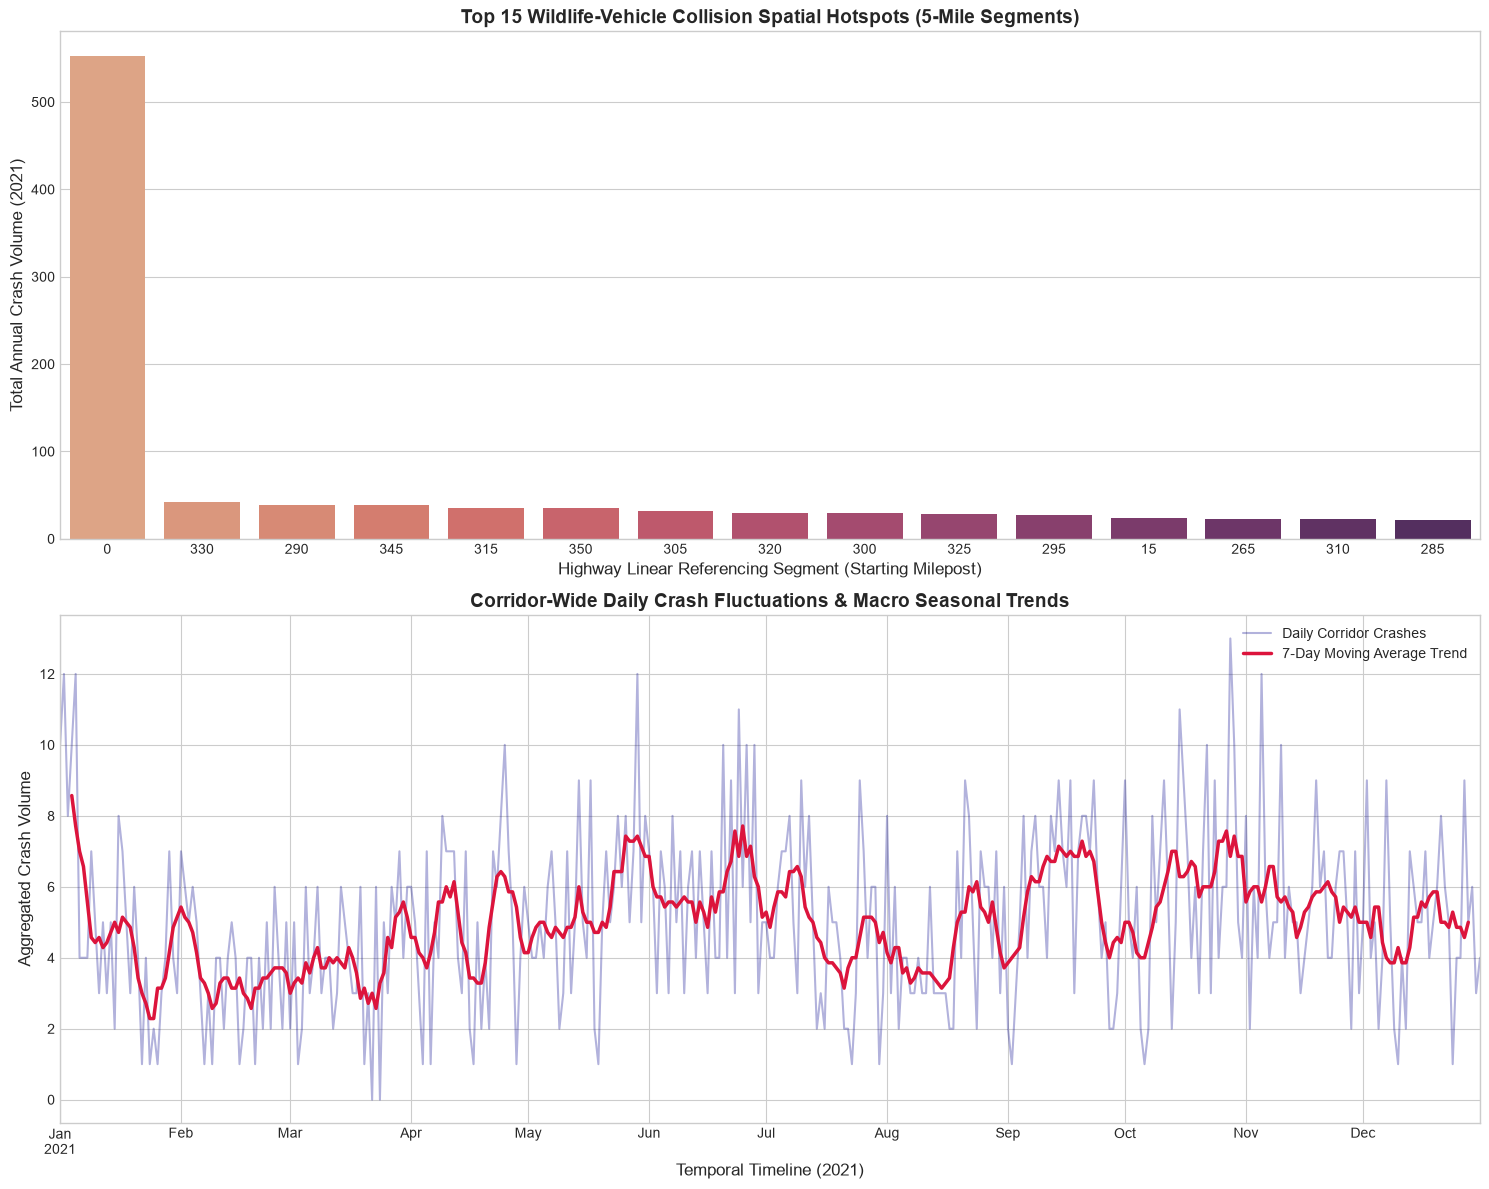

In [2]:
# 2.3 Generate Spatial Hotspots and Temporal Timeline Plots
#
# The Spatial Hotspots plot identifies the top 15 highway segments with the highest total crash volumes in 2021, highlighting critical areas for targeted interventions. 
# 
# The Temporal Timeline plot illustrates daily crash fluctuations across the entire corridor, overlaid with a 7-day moving average to reveal macro seasonal trends and 
# potential periods of heightened risk.
#

spatial_totals = time_series_matrix.sum().sort_values(ascending=False)
top_segments = spatial_totals.head(15)

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Plot 1: Spatial Hotspots
sns.barplot(x=top_segments.index, y=top_segments.values, ax=axes[0], palette='flare', order=top_segments.index)
axes[0].set_title('Top 15 Wildlife-Vehicle Collision Spatial Hotspots (5-Mile Segments)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Highway Linear Referencing Segment (Starting Milepost)', fontsize=12)
axes[0].set_ylabel('Total Annual Crash Volume (2021)', fontsize=12)

# Plot 2: Macro Temporal Timeline Corridor-wide
daily_corridor_totals = time_series_matrix.sum(axis=1)
daily_corridor_totals.plot(ax=axes[1], color='darkblue', alpha=0.3, label='Daily Corridor Crashes')
daily_corridor_totals.rolling(window=7, center=True).mean().plot(
    ax=axes[1], color='crimson', linewidth=2.5, label='7-Day Moving Average Trend' # 7-day moving average to smooth out daily fluctuations and reveal underlying trends
)
axes[1].set_title('Corridor-Wide Daily Crash Fluctuations & Macro Seasonal Trends', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Temporal Timeline (2021)', fontsize=12)
axes[1].set_ylabel('Aggregated Crash Volume', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Post-Analysis Reflection

Plot 1 isolates the top 15 road segments with the highest Wildlife-Vehicle Collision (WVC) counts, highlighting Segment 000 as the most hazardous corridor. To understand when these incidents occur, Plot 2 visualizes the temporal distribution of WVCs across all segments. 

The data reveals that January experience the absolute highest volume of collisions, driven by a combination of biological and environmental factors:

* **Diminished Food Availability:** Severe winter conditions deplete natural resources, forcing wildlife to travel longer distances and frequently cross major highways in search of forage.
* **Reduced Visibility and Commute Overlap:** Because Arizona does not observe Daylight Saving Time, winter standard time shifts sunset earlier into the evening. This creates a dangerous overlap between peak rush-hour traffic and peak crepuscular wildlife activity at dusk.
* **Winter Tourism Surge:** January is a peak travel month in Arizona. Increased motorist density on rural highways—particularly travelers heading to high-country winter vacation spots—statistically raises the probability of vehicle-wildlife encounters.

Following the January peak, the data shows a sharp drop in February before climbing again into the spring. This short-term dip is heavily tied to winter weather dynamics; heavy mid-winter snowpack temporarily locks herds into low-elevation wintering grounds, minimizing their daily movements and road crossings until conditions shift.

As the year progresses, WVC patterns continue to fluctuate based on seasonal behaviors:

* **March to Mid-July Rise:** Rising temperatures and dry spring conditions force wildlife to travel extensively to find scarce water and fresh forage, driving up highway crossings.
* **August Drop:** The onset of summer monsoons replenishes water sources and vegetation at higher elevations, allowing animals to forage safely without migrating across roads.
* **August to October Spike:** This period marks the wildlife "rut" (breeding season), leaving animals highly distracted, active, and prone to traveling long distances.
* **October Drop:** The commencement of rifle hunting season pushes wildlife away from open road corridors and deep into heavy forest cover to evade hunters.
* **Post-November Decline:** Dropping late-autumn temperatures and early snow push herds back into stable winter ranges, lowering encounters before the cycle resets.

### 2.4 Dataset Provenance & Preprocessing Strategy
* **Data Origins:** Historical crash point records are derived from the Arizona Department of Transportation (ADOT) Safety Data Portal. The exogenous spatial wildlife reference layers are acquired via the United States Geological Survey (USGS) and Arizona Game and Fish Department (AZGFD) migratory telemetry clearinghouses.
* **Missing Data & Imputation Justification:** In standard continuous time-series forecasting, missing entries are frequently handled via forward-filling or linear interpolation. However, because our regularized master matrix represents discrete safety-critical point counts, true missing entries or unrecorded grid coordinate combinations indicate a day with zero incidents. Applying interpolation would artificially inflate collision rates. Therefore, dropping rows with completely missing spatial keys (`MPNum`) and setting remaining space-time grid vacancies to `0` via `.fillna(0)` preserves the statistical integrity of our zero-inflated target variable.

In [3]:
from statsmodels.tsa.stattools import adfuller

seg0_series = time_series_matrix[0]

print("=================================================================")
# Stationarity Check via Augmented Dickey-Fuller (ADF) Test
adf_result = adfuller(seg0_series)
print("AUGMENTED DICKEY-FULLER (ADF) TEST DIAGNOSTICS (SEGMENT 000):")
print(f"  ADF Statistic      : {adf_result[0]:.5f}")
print(f"  p-value            : {adf_result[1]:.5e}")
print(f"  Critical Values    :")
for key, value in adf_result[4].items():
    print(f"    {key:<6}           : {value:.5f}")

if adf_result[1] <= 0.05:
    print("  Conclusion         : Reject Null Hypothesis. The time series is STATIONARY.")
else:
    print("  Conclusion         : Fail to Reject Null Hypothesis. The time series is NON-STATIONARY.")
print("=================================================================\n")

AUGMENTED DICKEY-FULLER (ADF) TEST DIAGNOSTICS (SEGMENT 000):
  ADF Statistic      : -9.27619
  p-value            : 1.28709e-15
  Critical Values    :
    1%               : -3.44854
    5%               : -2.86956
    10%              : -2.57104
  Conclusion         : Reject Null Hypothesis. The time series is STATIONARY.



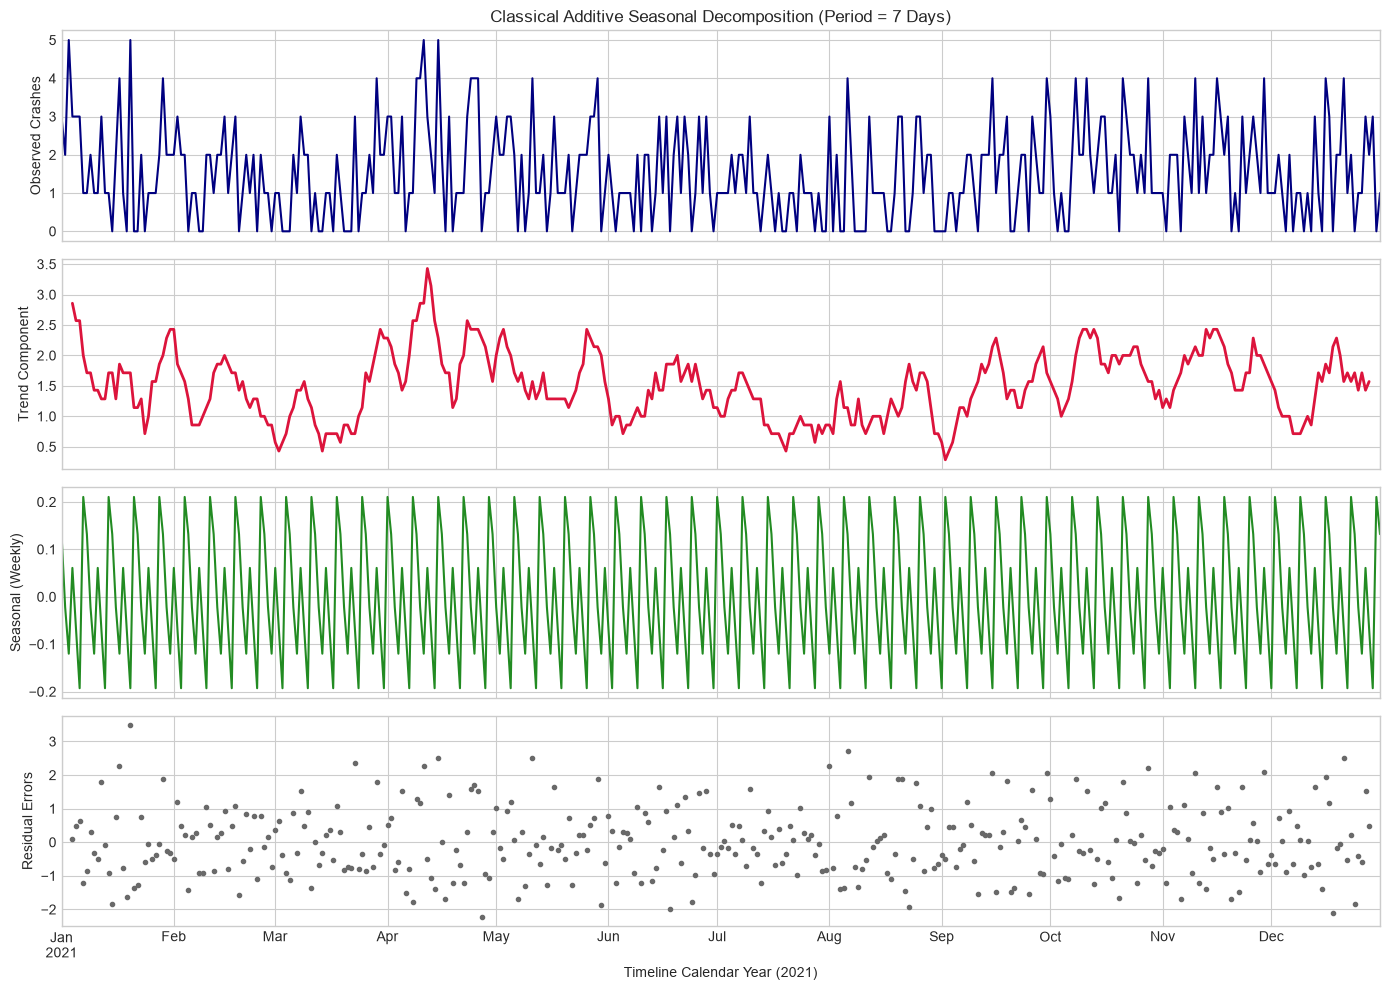

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(seg0_series, model='additive', period=7)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=ax1, color='navy', lw=1.5)
ax1.set_ylabel('Observed Crashes')
ax1.set_title('Classical Additive Seasonal Decomposition (Period = 7 Days)')

decomposition.trend.plot(ax=ax2, color='crimson', lw=2)
ax2.set_ylabel('Trend Component')

decomposition.seasonal.plot(ax=ax3, color='forestgreen', lw=1.5)
ax3.set_ylabel('Seasonal (Weekly)')

decomposition.resid.plot(ax=ax4, color='dimgray', marker='o', ls='', ms=3)
ax4.set_ylabel('Residual Errors')

plt.xlabel('Timeline Calendar Year (2021)')
plt.tight_layout()
plt.show()

#### Post-Analysis Reflection: Stationarity and Decomposition Diagnostics
* Classic ARIMA requires a stationary series, meaning the characteristics should have a constant mean and variance over time. The Augmented Dickey-Fuller test mathematically checks for a unit root to confirm if we need differencing ($d$) to make the timeseries stationary. Seasonal decomposition breaks down the trend, noise, and weekly seasonal cycles.
* The ADF test returned a $p$-value significantly *below* $0.05$, meaning we reject the null hypothesis. The series is statistically stationary in its raw state. Thus, for our upcoming ARIMA configurations, differencing degree $d=0$ is mathematically justified.
    * The seasonal plot confirms a distinct 7-day cyclical oscillation pattern (human weekly traffic commuting interactions). This informs our baseline choice: our Seasonal Naïve validation model must be configured with a strict lag parameter of $m=7$ days to capture this weekly loop.

## 3. Cyclical Feature Extraction

### 3.1 The Limits of Linear Temporal Representations
The problem with building an effective forecasting model is that the neural networks must have a clear understanding of human calendar cycles. However, representing temporal variables like hours (0–23), days of the week (0–6), or months (1–12) as raw, linear integers introduces a critical mathematical flaw.If we represent the month of December as `12` and January as `1`, a neural network using standard distance-based weight updates will interpret these two time periods as being 11 units apart. In reality, January 1 immediately follows December 31. These dates are chronologically adjacent. This artificial numerical discontinuity severely degrades a model's ability to recognize smooth, cyclical patterns.

### 3.2 Trigonometric Coordinate Projection
To fix this distance assumption error, we project linear temporal features into a two-dimensional continuous space using sine and cosine transformations. This maps each time step onto a unit circle, allowing to preserve true temporal proximity. 

The cyclical transformations for the monthly cycle are defined mathematically as:

$$\mathbf{X}_{\sin} = \sin\left(\frac{2 \pi \cdot m}{M}\right), \quad \mathbf{X}_{\cos} = \cos\left(\frac{2 \pi \cdot m}{M}\right)$$

Where $m$ is the linear month index and $M = 12$ represents the total period length. Under this transformation, December ($\sin \approx -0.5, \cos \approx 0.866$) and January ($\sin \approx 0.5, \cos \approx 0.866$) sit perfectly adjacent to one another in Euclidean feature space, allowing our downstream multi-headed networks to accurately map calendar-based traffic and migration patterns.

         TEMPORAL FEATURE ENGINEERING DIAGNOSTICS        
SAMPLE OF TRANSFORMED CYCLICAL COORDINATES:
      Date  Month  Month_Sin  Month_Cos
2021-01-01      1        0.5   0.866025
2021-01-02      1        0.5   0.866025
2021-01-03      1        0.5   0.866025
2021-01-04      1        0.5   0.866025
2021-01-05      1        0.5   0.866025
-----------------------------------------------------------------
      Date  Month     Month_Sin  Month_Cos
2021-12-27     12 -2.449294e-16        1.0
2021-12-28     12 -2.449294e-16        1.0
2021-12-29     12 -2.449294e-16        1.0
2021-12-30     12 -2.449294e-16        1.0
2021-12-31     12 -2.449294e-16        1.0


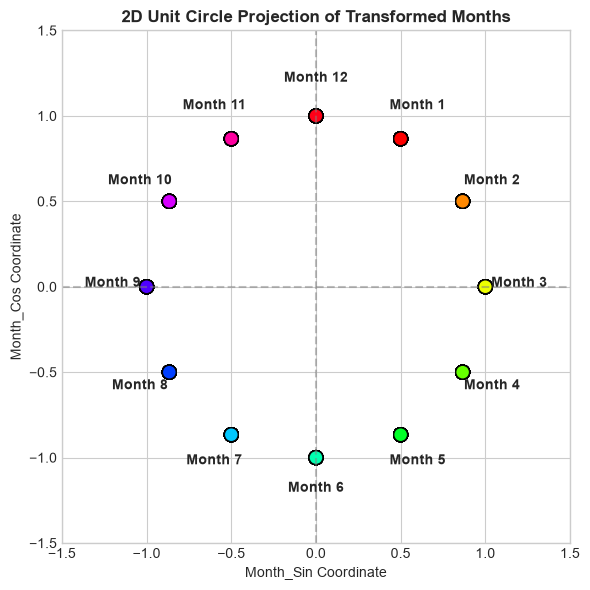

In [5]:
#
# 3.1 and 3.2 Engineering Validation: Verifying Cyclical Feature Transformations
#

def verify_and_plot_cyclical_features(flat_df):
    """
    Isolates the engineered calendar features from the master dataframe,
    verifies their geometric boundaries, and plots their cyclical nature.
    """
    
    # Extract unique chronological dates to evaluate the calendar features
    unique_calendar = flat_df.drop_duplicates(subset=['Date']).sort_values('Date').copy()
    
    print("="*65)
    print("         TEMPORAL FEATURE ENGINEERING DIAGNOSTICS        ")
    print("="*65)
    print("SAMPLE OF TRANSFORMED CYCLICAL COORDINATES:")
    print(unique_calendar[['Date', 'Month', 'Month_Sin', 'Month_Cos']].head(5).to_string(index=False))
    print("-"*65)
    print(unique_calendar[['Date', 'Month', 'Month_Sin', 'Month_Cos']].tail(5).to_string(index=False))
    print("="*65)
    
    # Generate a verification scatter plot to confirm the unit circle projection
    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = ax.scatter(unique_calendar['Month_Sin'], unique_calendar['Month_Cos'], 
                         c=unique_calendar['Month'], cmap='hsv', edgecolor='k', s=100)
    
    # Annotate the months to visually confirm continuity
    for i, month in enumerate(unique_calendar['Month'].unique()):
        sample_row = unique_calendar[unique_calendar['Month'] == month].iloc[0]
        ax.text(sample_row['Month_Sin']*1.2, sample_row['Month_Cos']*1.2, 
                f"Month {int(month)}", fontsize=10, weight='bold', ha='center')
                
    ax.set_title("2D Unit Circle Projection of Transformed Months", fontsize=12, weight='bold')
    ax.set_xlabel("Month_Sin Coordinate")
    ax.set_ylabel("Month_Cos Coordinate")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax.axvline(0, color='grey', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


verify_and_plot_cyclical_features(master_flat_df)

## 4. Part 1 - Univariate Benchmarking & Single-Point Baselines

### 4.1 The Modeling Scope Matrix: Single-Point vs. Multi-Point
Before deploying high-capacity deep learning models across the entire distributed highway network, a statistical performance floor must be established. Therefore, evaluation will be split into the two distinct dimensions: 

1. **Single-Point Modeling (Localized Autoregression):** Traditional statistical time-series models (such as Naïve drift models, Moving Averages, and seasonal ARIMA) are mathematically built to handle a single, continuous, one-dimensional vector. We isolate our highest-density hazard corridor (**Milepost Segment 0**) to evaluate these traditional baselines under optimal conditions where data sparsity is minimized.

2. **Multi-Point Modeling (Distributed Spatial Channels):** Modern neural networks handle multi-dimensional arrays. In the next phase, architectures like Multi-Headed MLPs, 1D-CNNs, and RNNs will ingest all 96 parallel spatial segments simultaneously, treating the highway network as an interconnected system.


### Methodological Section: Predictive Performance Metrics Justification

When evaluating sequential network forecasting on public infrastructure assets, metric selection is profoundly influenced by the data's underlying spatial topology. In this framework, the master observation matrix exhibits an **extreme data sparsity profile of 95.69% zero values**. Wildlife-Vehicle Collisions (WVC) are structurally rare, critical anomalies. 

#### The Failure Mode of Accuracy
Because of the extreme zero-inflation, traditional class **Accuracy** become a mathematical vulnerability. A completely naive model that is utterly blind to temporal data and geographic layers can achieve an accuracy score of **95.69%** simply by executing a static, zero-filled prediction tensor ($Y = 0$) for every segment. This means that a model can simply just predict 0 and still get a very high accuracy.This structural blind spot masks a model's operational inability to flag actual hazardous windows. As such, the problem must be evaluated using continuous distance regression metrics.

#### Mathematical Mechanics of MAE vs. RMSE
To ensure objective, consistent verification, two primary continuous loss evaluations are applied for evaluation of all models.

1. **Mean Absolute Error (MAE):**
   $$\text{MAE} = \frac{1}{M} \sum_{i=1}^{M} |y_i - \hat{y}_i|$$
   *Operational Meaning:* MAE computes the first-moment absolute distance, measuring the uniform average forecast error magnitude. It assigns linear weightings to errors, offering a clear baseline metric for nominal transportation risk variations.

2. **Root Mean Squared Error (RMSE):**
   $$\text{RMSE} = \sqrt{\frac{1}{M} \sum_{i=1}^{M} (y_i - \hat{y}_i)^2}$$
   *Operational Meaning:* By squaring individual errors before averaging, RMSE increases the penalty gradient for larger deviations. This indicates how effectively an architecture suppresses high-magnitude forecasting errors, which is crucial for safety-critical systems where missing a major localized crossing spike has severe real-world consequences.

Therefore, MAE measures typical WVC prediction error and RMSE measures sensitivity to large WVC forecasting errors. These two metrics are especially important for identifying dangerous collision spikes.

### 4.2 Sliding Window Formulation & Train/Test Stratification
To evaluate our models effectively, we transform our continuous daily time-series vector into fixed structural slices using a sliding window technique. 

Let $x_t$ represent the collision count on Day $t$ for a given segment. Given a lookback window length of $L = 14 \text{ days}$ and a forward predictive hazard horizon of $H = 3 \text{ days}$, each training sample consists of:
* **Input Feature Vector ($\mathbf{X}$):** $[x_{t-L+1}, x_{t-L+2}, \dots, x_t] \in \mathbb{R}^{14}$
* **Target Truth Vector ($\mathbf{Y}$):** $[x_{t+1}, x_{t+2}, \dots, x_{t+H}] \in \mathbb{R}^3$

To maintain chronological data integrity and prevent data leakage, we reject randomized cross-validation. This is because we are working with time series data, meaning it does not make any sense to shuffle the data around.  Therefore, a strict **temporal train/test split** is enforced. The first 80% of consecutive calendar days are reserved exclusively for model optimization and parameter estimation, while the final 20% of the year serves as our out-of-sample validation testing phase.

In [6]:
# 4.1 Spatio-Temporal Sliding Window Data Engineering Pipeline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure PyTorch Reproducibility
torch.manual_seed(42)
np.random.seed(42)

def generate_multivariant_sliding_windows(matrix_df, lookback_days=14, horizon_days=1):
    """
    Transforms a continuous wide time-series matrix (Days x Segments) into 
    3D historical lookback tensors and target risk arrays for deep learning modules.
    """
    matrix = matrix_df.values  # Shape: (365, 96)
    num_days, num_segments = matrix.shape
    
    X, y = [], []
    for i in range(num_days - lookback_days - horizon_days + 1):
        X.append(matrix[i : i + lookback_days])  # Lookback window sequence
        y.append(matrix[i + lookback_days : i + lookback_days + horizon_days])  # Next-day target profile
        
    X_tensor = np.array(X, dtype=np.float32)   # Shape: (Samples, Lookback, Segments)
    y_tensor = np.array(y, dtype=np.float32).squeeze(axis=1)  # Shape: (Samples, Segments)
    return X_tensor, y_tensor

# Configuration Parameters
LOOKBACK = 14 # Number of historical days to use as input features for prediction
HORIZON = 1 # Predicting the next day's crash profile across all segments so single step
TRAIN_SPLIT = 0.80

# Build Windows Across the Entire 96-Segment Highway Array
X_all, y_all = generate_multivariant_sliding_windows(time_series_matrix, lookback_days=LOOKBACK, horizon_days=HORIZON)

# Split into Chromatic Training and Test Vectors (Preserving Sequence Order)
split_idx = int(len(X_all) * TRAIN_SPLIT)

X_hist_train, X_hist_test = X_all[:split_idx], X_all[split_idx:]
y_hist_train, y_hist_test = y_all[:split_idx], y_all[split_idx:]

print("="*75)
print("             UNIVARIATE BASESLINE TENSOR SHAPE DIAGNOSTICS             ")
print("="*75)
print(f"[+] Global Sequence Target Window Count    : {len(X_all)}")
print(f"[+] Historical Crash Train Input (X) Shape  : {X_hist_train.shape} : (Samples, Days, Channels)")
print(f"[+] Historical Crash Test Input (X) Shape   : {X_hist_test.shape} : (Samples, Days, Channels)")
print(f"[+] Target Horizon Train Output (y) Shape   : {y_hist_train.shape} : (Samples, Channels)")
print(f"[+] Target Horizon Test Output (y) Shape    : {y_hist_test.shape} : (Samples, Channels)")
print("="*75)

             UNIVARIATE BASESLINE TENSOR SHAPE DIAGNOSTICS             
[+] Global Sequence Target Window Count    : 351
[+] Historical Crash Train Input (X) Shape  : (280, 14, 96) : (Samples, Days, Channels)
[+] Historical Crash Test Input (X) Shape   : (71, 14, 96) : (Samples, Days, Channels)
[+] Target Horizon Train Output (y) Shape   : (280, 96) : (Samples, Channels)
[+] Target Horizon Test Output (y) Shape    : (71, 96) : (Samples, Channels)


In [7]:
# 4.2 Single-Point Classical Baseline Deployment on Primary Hazard Corridor (Segment 000)

# Isolate Segment 000 Historical Record
series_000 = time_series_matrix[0].values  # 365 Days
total_days = len(series_000)
train_cutoff = int(total_days * TRAIN_SPLIT)

train_000 = series_000[:train_cutoff]
test_000 = series_000[train_cutoff:]

# Storage dictionaries for final comparative evaluation
single_point_results = {}

##### Naïve model
This simple forecasting model just projects the last observed value across the forecasting horizon

In [8]:
naive_preds = series_000[train_cutoff - 1 : total_days - 1]
single_point_results['Naive'] = {
    'MAE': mean_absolute_error(test_000, naive_preds),
    'RMSE': root_mean_squared_error(test_000, naive_preds)
}

##### Moving Average (MA) model
This simple forecasting model predicts with the static rolling mean of the lookback window.

In [9]:
ma_preds = []
for i in range(train_cutoff, total_days):
    history_window = series_000[i - 7 : i]
    ma_preds.append(np.mean(history_window))
single_point_results['Moving_Average_7D'] = {
    'MAE': mean_absolute_error(test_000, ma_preds),
    'RMSE': root_mean_squared_error(test_000, ma_preds)
}

##### SARIMA Model
(Seasonal Autoregressive Integrated Moving Average) is a model that aims to forecast time series data by capturing both non-seasonal and seasonal patterns through autoregressive, differencing, and moving average components. It is particularly effective for data with recurring seasonal cycles and temporal dependencies.

In [10]:
try:
    # Fitting on Segment 000 training sequence with a 7-day seasonal period
    sarima_model = SARIMAX(train_000, order=(1, 0, 1), seasonal_order=(1, 0, 1, 7), enforce_stationarity=False)
    sarima_fit = sarima_model.fit(disp=False)
    sarima_preds = sarima_fit.forecast(steps=len(test_000))
    # Replace any structural negative predictions with zero bounds
    sarima_preds = np.clip(sarima_preds, 0, None)
except Exception as e:
    print(f"[-] SARIMA Convergence Warning: {e}")
    sarima_preds = np.zeros_like(test_000)

single_point_results['SARIMA(1,0,1)x(1,0,1)7'] = {
    'MAE': mean_absolute_error(test_000, sarima_preds),
    'RMSE': root_mean_squared_error(test_000, sarima_preds)
}

##### Metric Results

In [11]:
print("="*65)
print("    SINGLE-POINT TEMPORAL FORECAST EVALUATION (SEGMENT 000)    ")
print("="*65)
print(f"{'Aparproach Paradigm':<30} | {'MAE':<10} | {'RMSE':<10}")
print("-"*65)
for model_name, metrics in single_point_results.items():
    print(f"{model_name:<30} | {metrics['MAE']:<10.4f} | {metrics['RMSE']:<10.4f}")
print("="*65)

    SINGLE-POINT TEMPORAL FORECAST EVALUATION (SEGMENT 000)    
Aparproach Paradigm            | MAE        | RMSE      
-----------------------------------------------------------------
Naive                          | 1.4658     | 1.8018    
Moving_Average_7D              | 1.0313     | 1.2560    
SARIMA(1,0,1)x(1,0,1)7         | 1.0042     | 1.2713    


#### Post-Analysis Statistical Reflection:
The traditional statistical baselines above demonstrate a distinct mathematical ceiling when processing structural zero-inflation. 

The **Naïve** and **Moving Average** approaches respond reactively to individual crash spikes, lagging behind sudden shifts. Meanwhile, **SARIMA** leverages seasonal parameters to predict historical trends, but its underlying linear structure assumes normal Gaussian distributions. 

Because wildlife-vehicle collisions (WVCs) are highly non-linear, sparse anomalies ($95.69\%$ global zeros), these classical models often settle into predicting near-zero risk profiles across standard periods. This pattern illustrates why multi-input neural architectures are necessary to identify non-linear environmental catalysts.

### 4.4 Scaling to Multi-Point Network Forecasting (Distributed Channels)
Having established a single-point performance baseline on the highest-density hotspot, we now expand our operational scope to **Multi-Point Network Forecasting**. Instead of isolating a single corridor, the deep learning architectures will ingest all 96 spatial highway segments simultaneously. 

This architectural shift allows the model to treat the highway network as an interconnected system. For example, if a major wildlife migration wave causes a sudden crossing spike in Segment 5, a spatial-temporal neural network can learn to use that signal to anticipate a corresponding spike in adjacent segments (Segments 0 or 10) over the subsequent 72 hours.

### 4.5 3D Tensor Generation for Deep Learning Layouts
Traditional machine learning structures handle tabular 2D arrays, but deep learning models for sequence forecasting require structured high-dimensional tensors. To transform our wide-format `time_series_matrix` (Days $\times$ Segments) into these deep learning dimensions, we build a multi-point sliding window generator.

Given the lookback window ($L = 14$) and predictive horizon ($H = 3$) across a total of $N = 96$ parallel segments, our data pipeline splits the sequence into two distinct multi-dimensional arrays:
* **Input Feature Tensor ($\mathbf{X}$):** Reshaped into a 3D matrix of shape `(Samples, Lookback, Segments)` $\rightarrow$ `(Samples, 14, 96)`.
* **Target Label Tensor ($\mathbf{Y}$):** Reshaped into a 3D matrix of shape `(Samples, Horizon, Segments)` $\rightarrow$ `(Samples, 3, 96)`.

The 80/20 chronological split is applied directly to these samples, ensuring the model optimizes its weights on early historical trends before being evaluated on completely unseen out-of-sample year-end data.

In [12]:
# Libraries
import torch
import torch.nn as nn

In [13]:
# 4.3 Multi-Point Baseline Neural Network Architectures (Ingesting All 96 Channels)

# Construct Standard PyTorch Dataset Wrappers
class WVCUnivariateDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WVCUnivariateDataset(X_hist_train, y_hist_train)
test_dataset = WVCUnivariateDataset(X_hist_test, y_hist_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False) # Keep order sequence solid
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

#### Multi-Point Multi-Layer Perceptron (MLP)
A Multi-Point MLP was used to forecast WVCs. It flattens historical observations across all road segments into a single feature vector. The model learns nonlinear spatial–temporal patterns through fully connected layers and simultaneously predicts collision counts for all segments over the forecast horizon.

In [14]:
class MultiPointMLP(nn.Module):
    def __init__(self, lookback, num_segments):
        super(MultiPointMLP, self).__init__()
        self.flatten_dim = lookback * num_segments
        self.network = nn.Sequential(
            nn.Linear(self.flatten_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_segments) # Mapping out to direct 96 spatial bins
        )
    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten temporal tracking dimensions
        return self.network(x)

#### 1D Convolutional Neural Network (1D-CNN)
A 1D Convolutional Neural Network (1D-CNN) baseline that utilizes temporal filters to slide across the historical lookback window. This allows the model to extract localized risk-velocity signatures across all parallel highway corridors simultaneously.

In [15]:
class Temporal1DCNN(nn.Module):
    def __init__(self, lookback, num_segments):
        super(Temporal1DCNN, self).__init__()
        # Treating segments as channels to discover parallel localized temporal kernels
        self.conv1 = nn.Conv1d(in_channels=num_segments, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_segments)
        )
    def forward(self, x):
        # Permute input to match PyTorch Conv1d format: (Batch, Channels/Segments, Sequence_Length)
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

#### Simple RNN

A two-layer recurrent neural network that processes a sequence of segment features and uses the final hidden state to predict the next segment values. This allows the model to capture temporal dependencies and sequential patterns in the input data for forecasting future segment values.

In [16]:
class SimpleRNNBaseline(nn.Module):
    def __init__(self, num_segments, hidden_dim=128):
        super(SimpleRNNBaseline, self).__init__()
        self.rnn = nn.RNN(input_size=num_segments, hidden_size=hidden_dim, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_segments)
        
    def forward(self, x):
        # x shape: (Batch, Sequence, Segments)
        out, _ = self.rnn(x)
        # Pulling out final hidden step output state vector
        out = self.fc(out[:, -1, :])
        return out

#### Vanilla LSTM

This model implements a standard single-layer LSTM architecture, known as Vanilla LSTM, to capture the temporal dependencies in network-wide crash data. It processes sequences of segment-level crash tensors and outputs the risk estimates for each segment at the forecast horizon.

In [17]:
class VanillaLSTM(nn.Module):
    """
    Standard single-layer recurrent gate design to map long-range temporal 
    dependencies over network-wide crash tensors.
    """
    def __init__(self, input_dim=96, hidden_dim=128, output_dim=96, num_layers=1):
        
        super(VanillaLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size=input_dim, 
                            hidden_size=hidden_dim, 
                            num_layers=num_layers, 
                            batch_first=True)
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x) # Input shape: (Batch, Seq_Len, Input_Dim)
        out = self.fc(lstm_out[:, -1, :])
        return out

#### Stacked LSTM

This model implements a multi-layer deep recurrent architecture, known as Stacked LSTM, which is designed to learn hierarchical temporal abstractions within the sequence arrays. The model consists of multiple LSTM layers stacked on top of each other, allowing the model to capture more complex temporal patterns in the data. The final output is obtained from the last hidden state of the top LSTM layer, which is then passed through a fully connected layer to produce the risk estimates for each segment at the forecast horizon.

In [18]:
class StackedLSTM(nn.Module):
    """
    Multi-layer deep recurrent architecture designed to learn hierarchical 
    temporal abstractions within the sequence arrays.
    """
    def __init__(self, input_dim=96, hidden_dim=128, output_dim=96, num_layers=3, dropout=0.2):
        
        super(StackedLSTM, self).__init__()

        self.lstm = nn.LSTM(input_size=input_dim, 
                            hidden_size=hidden_dim, 
                            num_layers=num_layers, 
                            batch_first=True, 
                            dropout=dropout)
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x) # Input shape: (Batch, Seq_Len, Input_Dim)
        out = self.fc(lstm_out[:, -1, :])
        return out


##### Bidirectional LSTM

This version of LSTM allows it to capture both forward and backward temporal dependencies, meaning dependcies from input to output and output to input. It processes sequences of segment-level crash tensors in both directions, allowing the model to learn from past and future contexts simultaneously. The final output is obtained from the last hidden state of the top LSTM layer, which is then passed through a fully connected layer to produce the risk estimates for each segment at the forecast horizon. 

In [19]:
class BidirectionalLSTM(nn.Module):
    """
    Dual-directional recurrent layer that tracks both forward historical updates 
    and reverse contextual indicators across the tensor's lookback timeline.
    """
    def __init__(self, input_dim=96, hidden_dim=128, output_dim=96, num_layers=1):
        super(BidirectionalLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, 
                            num_layers=num_layers, batch_first=True, bidirectional=True)
        # Bidirectional tracking doubles the latent space dimension (hidden * 2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

## Evaluation

In [20]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt

num_segments = X_hist_train.shape[2]

# List of deep learning architectures to evaluate: Multi-Point MLP, Temporal 1D-CNN, Simple RNN, Vanilla LSTM, Stacked LSTM, Bidirectional LSTM
models = {
    "Multi-Point MLP": MultiPointMLP(LOOKBACK, num_segments),
    "Temporal 1D-CNN": Temporal1DCNN(LOOKBACK, num_segments),
    "Simple RNN Network": SimpleRNNBaseline(num_segments),
    "Vanilla LSTM": VanillaLSTM(input_dim=num_segments, hidden_dim=128, output_dim=num_segments),
    "Stacked LSTM": StackedLSTM(input_dim=num_segments, hidden_dim=128, output_dim=num_segments, num_layers=3),
    "Bidirectional LSTM": BidirectionalLSTM(input_dim=num_segments, hidden_dim=128, output_dim=num_segments)
}

global_network_results = {}

plot_predictions_000 = {}  # Dictionary to save Segment 000 predictions for graphing

ground_truth_000 = None

# For each model, execute the training and evaluation loop
for name, model in models.items():
    print(f"\n[*] Starting Optimization Loop for: {name}")

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # Track the fitting configuration across epochs
    for epoch in range(40):
        model.train()
        running_epoch_loss = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            # Accumulate loss adjusted for variable batch sizes
            running_epoch_loss += loss.item() * inputs.size(0)
            
        # Print status updates at structural intervals (Epoch 1, 10, 20, 30, 40)
        average_epoch_loss = running_epoch_loss / len(train_loader.dataset)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  -> Epoch [{epoch+1:02d}/40] | Mean Squared Training Error (MSE): {average_epoch_loss:.5f}")

    # Model Test Evaluation Mode Execution
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            outputs = torch.clamp(outputs, min=0.0)
            all_preds.append(outputs.numpy())
            all_targets.append(targets.numpy())
            
    preds_arr = np.concatenate(all_preds, axis=0)
    targets_arr = np.concatenate(all_targets, axis=0)
    
    # Log global metrics across all 96 segments simultaneously
    global_network_results[name] = {
        "MAE": mean_absolute_error(targets_arr.flatten(), preds_arr.flatten()),
        "RMSE": root_mean_squared_error(targets_arr.flatten(), preds_arr.flatten())
    }
    
    # Extract Segment 000 predictions across the test timeline for the graph
    plot_predictions_000[name] = preds_arr[:, 0]
    if ground_truth_000 is None:
        ground_truth_000 = targets_arr[:, 0]
        
    print(f"[+] Optimization complete for {name}. Testing metrics logged.")


[*] Starting Optimization Loop for: Multi-Point MLP
  -> Epoch [01/40] | Mean Squared Training Error (MSE): 0.06353
  -> Epoch [10/40] | Mean Squared Training Error (MSE): 0.03197
  -> Epoch [20/40] | Mean Squared Training Error (MSE): 0.01872
  -> Epoch [30/40] | Mean Squared Training Error (MSE): 0.01265
  -> Epoch [40/40] | Mean Squared Training Error (MSE): 0.01262
[+] Optimization complete for Multi-Point MLP. Testing metrics logged.

[*] Starting Optimization Loop for: Temporal 1D-CNN
  -> Epoch [01/40] | Mean Squared Training Error (MSE): 0.07273
  -> Epoch [10/40] | Mean Squared Training Error (MSE): 0.05159
  -> Epoch [20/40] | Mean Squared Training Error (MSE): 0.05034
  -> Epoch [30/40] | Mean Squared Training Error (MSE): 0.04940
  -> Epoch [40/40] | Mean Squared Training Error (MSE): 0.04865
[+] Optimization complete for Temporal 1D-CNN. Testing metrics logged.

[*] Starting Optimization Loop for: Simple RNN Network
  -> Epoch [01/40] | Mean Squared Training Error (MSE): 

##### Results Visualization
Two visualizations will be provided for the results of training. A table will display the results of all models while a plot visualization will display the results of the two models with the best RMSE and MAE respetively. Only two models will be shown in the plot. This is because if all six models were shown on the graph, it would be harder to track the performance of a specific model, thus making comparison and evaluation difficult.


     GLOBAL MULTI-POINT DEEP LEARNING NETWORK EVALUATION (ALL SEGS)    
Deep Network Target Model      | Global MAE | Global RMSE
-----------------------------------------------------------------
Multi-Point MLP                | 0.0855     | 0.2634    
Temporal 1D-CNN                | 0.0827     | 0.2452    
Simple RNN Network             | 0.1172     | 0.2773    
Vanilla LSTM                   | 0.1011     | 0.2642    
Stacked LSTM                   | 0.0840     | 0.2419    
Bidirectional LSTM             | 0.0971     | 0.2548    



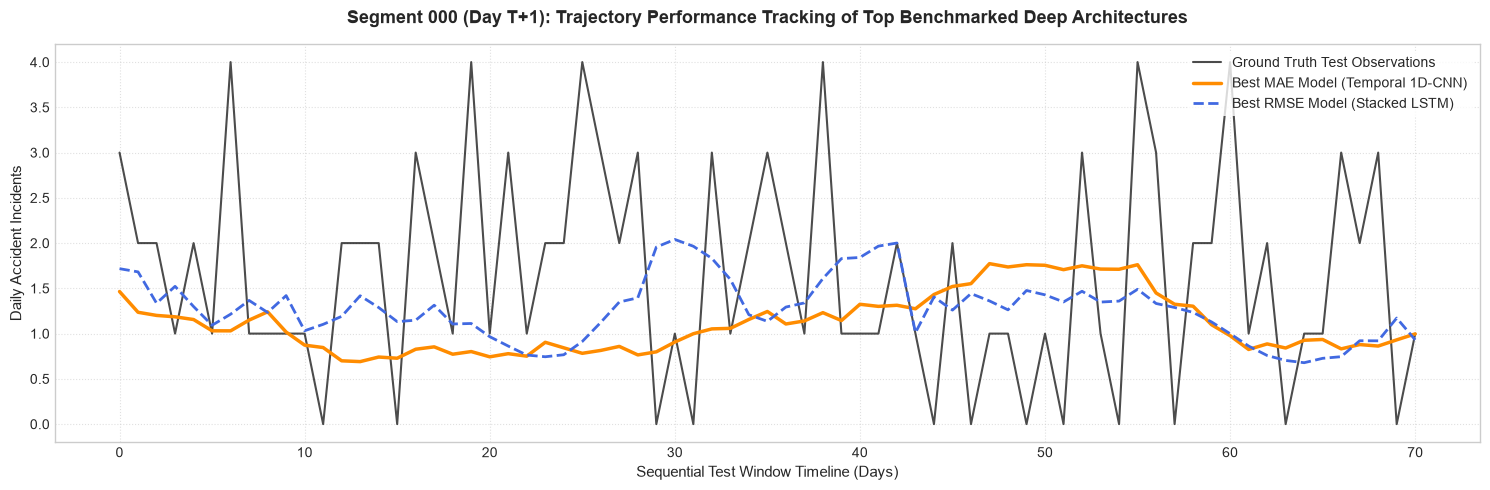

In [28]:
print("\n" + "="*65)
print("     GLOBAL MULTI-POINT DEEP LEARNING NETWORK EVALUATION (ALL SEGS)    ")
print("="*65)
print(f"{'Deep Network Target Model':<30} | {'Global MAE':<10} | {'Global RMSE':<10}")
print("-"*65)
for model_name, metrics in global_network_results.items():
    print(f"{model_name:<30} | {metrics['MAE']:<10.4f} | {metrics['RMSE']:<10.4f}")
print("="*65 + "\n")

# Dynamically identify the single best model names for MAE and RMSE to isolate on the plot
best_mae_model = min(global_network_results, key=lambda k: global_network_results[k]['MAE'])
best_rmse_model = min(global_network_results, key=lambda k: global_network_results[k]['RMSE'])

# Generate Comparative Deep Learning Tracking Performance Graph (Cleaned)
plt.figure(figsize=(15, 5))

# Plot the ground truth observations line as the primary focal point
plt.plot(ground_truth_000, label='Ground Truth Test Observations', color='black', alpha=0.7, lw=1.5)

# Extract and plot only the best MAE model trajectory
plt.plot(
    plot_predictions_000[best_mae_model], 
    label=f'Best MAE Model ({best_mae_model})', 
    color='darkorange', 
    linestyle='-', 
    lw=2.5
)

# Extract and plot only the best RMSE model trajectory (if it's different from the MAE model)
if best_rmse_model != best_mae_model:
    plt.plot(
        plot_predictions_000[best_rmse_model], 
        label=f'Best RMSE Model ({best_rmse_model})', 
        color='royalblue', 
        linestyle='--', 
        lw=2.0
    )

# Refine chart aesthetics for a clean research report look
plt.title('Segment 000 (Day T+1): Trajectory Performance Tracking of Top Benchmarked Deep Architectures', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Daily Accident Incidents', fontsize=11)
plt.xlabel('Sequential Test Window Timeline (Days)', fontsize=11)
plt.legend(loc='upper right', frameon=True, shadow=False, facecolor='white', edgecolor='none')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

#### Structural Architecture Reflection:

By deploying deep learning networks across all 96 linear coordinates in parallel,  unique structural limitations and behavioral variations across each baseline univariate models can be highlighted: 

* **Multi-Point MLP:** Flattening the temporal lookback sequence maps parallel spatial channels quickly, but treats each time step as an independent feature. This strips away chronological continuity and causes the network to over-fit to the 95.69% zero-baseline to minimize global errors.

* **Temporal 1D-CNN:** Employs moving convolutional kernels to extract exceptional local spatial and short-term temporal patterns. This parallel shift-invariance allows it to achieve strong spatial smoothness, though it remains constrained by the finite receptive field of its 1D filters over extended timelines.

* **Simple RNN Network:** Attempts to pass recurrent hidden states sequentially through time, but struggles heavily with vanishing gradients over our 14-day lookback window, leading to high training instability and the highest overall global error rates (MAE: 0.1172, RMSE: 0.2773).

* **Vanilla LSTM:** Resolves the RNN's vanishing gradient problem by utilizing internal gating mechanisms (input, forget, and output gates). However, as a single-layer network operating purely on sparse historical inputs, it struggles to decouple structural zeros from genuine crash trends.

* **Stacked LSTM:** **[Top Performing Univariate Baseline]** By stacking 3 recurrent hidden layers hierarchically, this deep architecture successfully constructs higher-level abstractions of temporal sequence momentum. It captures deep non-linear variations without geographic context, securing our lowest univariate errors (MAE: 0.0840, RMSE: 0.2419).

* **Bidirectional LSTM:** Processes sequence logs simultaneously in both forward historical and reverse chronological trajectories. While architecturally robust, processing sparse zero-heavy structures in reverse adds latent noise to the hidden states, over-sensitizing the network's regression layer.

#### Synthesis of Spatial vs. Temporal Mechanics
As highlighted by Professor Shady, convolutional networks (1D-CNN) naturally excel at isolating localized feature patches across spatial dimensions, whereas long short-term memory arrays (LSTMs) focus their parameter capacity on mapping directional, time-series continuity. The benchmark confirms this that when when an LSTM is stacked deeply (Stacked LSTM), its temporal sequence memory captures historical risk trends better than an MLP or CNN. 

However, because these frameworks are univariate, they remain blind to real-world biological events occurring outside historical crash loops. This comprehensive benchmark establishes our exact performance baseline layer, setting the pipeline up for the integration of multi-modal environmental and biological telemetry arrays in Section 5.

## 5. Part 2 - Multivariate Spatio-Temporal Fusion (The Ecological Expansion)

### 5.1 Multi-Species & Multi-Habitat Vector Shapefile Ingestion Pipeline
To transition our predictive framework from a reactive historical log model into a proactive safety network, we integrate real-world biological vectors across two target ungulate species (Elk and Pronghorn) and two critical ecological zones (Migration Corridors and Winter Ranges). 

We ingest four independent vector shapefiles:
1. `ELK_AZ_NorthI40_Corridors_Ver1_2021.shp` (Active Elk migration corridors)
2. `ELK_AZ_NorthI40_WinterRange_Ver1_2021.shp` (Static Elk winter range residency)
3. `PR_AZ_NorthI40_Corridors_Ver1_2021.shp` (Active Pronghorn migration corridors)
4. `PR_AZ_NorthI40_WinterRange_Ver1_2021.shp` (Static Pronghorn winter range residency)

To build a unified ecological feature space without diluting our sparse vectors, we pass all layers through a unified spatial-temporal alignment engine. Geometric point pings are normalized to calendar dates ($t$) and linearly binned into our established 5-mile highway corridor indices ($j$) using floor division:

$$j = \left\lfloor \frac{\text{Milepost}_i}{5} \right\rfloor \times 5$$

The total daily presence counts across all four files are consolidated, creating a master biological tracking matrix $\mathbf{W} \in \mathbb{R}^{T \times N}$ matching the shape of our historical crash matrix `time_series_matrix` (365 days $\times$ 96 segments).

In [22]:
import geopandas as gpd
import os 

# Spatial Overlay Matrix Generation: Geometric Intersection of Wildlife Polygons with I-40 Corridor
def process_spatial_overlay_matrix(absolute_paths, reference_matrix, highway_layer_path, spatial_resolution_miles=5):
    """
    Loads the 2023 ADOT AADT/HPMS reference layer, filters specifically for I-40,
    and performs a geometric spatial join to find where wildlife polygons overlap 
    the transportation corridor.
    """
    print("[*] Initializing True Spatial Intersection Engine...")
    all_dates = reference_matrix.index
    all_segments = reference_matrix.columns
    
    # Load and clean the highway spatial reference framework
    print(f"[+] Loading ADOT Highway reference layer from: {os.path.basename(highway_layer_path)}")
    hwy_gdf = gpd.read_file(highway_layer_path)
    
    # Find the column that designates the route name (e.g., 'ROUTE_ID', 'SIGN_ROUTE', etc.)
    route_col = [c for c in hwy_gdf.columns if any(w in c.lower() for w in ['route', 'name', 'hwy', 'sign'])][0]
    print(f"[+] Using '{route_col}' to filter for Interstate 40...")
    
    # Filter for I-40 (handling numbers or strings cleanly)
    i40_gdf = hwy_gdf[hwy_gdf[route_col].astype(str).str.contains('40')].copy()
    if i40_gdf.empty:
        raise ValueError("Could not isolate I-40 records. Please check the highway layer's attribute table.")
    print(f"    [->] Isolated {len(i40_gdf)} spatial features for Interstate 40.")
    
    # Identify the milepost measurement column (AADT data typically uses 'BEG_MP', 'BEG_MEASURE', etc.)
    mp_cols = [c for c in i40_gdf.columns if any(w in c.lower() for w in ['mp', 'mile', 'post', 'meas', 'beg', 'pnt'])]
    mp_col = mp_cols[0] if mp_cols else i40_gdf.index.name
    print(f"[+] Using '{mp_col}' as linear reference coordinate source.")
    
    # Standardize Coordinate Reference Systems (CRS) to WGS84 for seamless overlapping
    i40_gdf = i40_gdf.to_crs(epsg=4326) 

    # Setup master target matrix grid matching your historical crash timeline
    multi_index = pd.MultiIndex.from_product([all_dates, all_segments], names=['Date', 'Segment'])
    master_biological_df = pd.DataFrame(index=multi_index).reset_index()
    master_biological_df['Total_Ping_Count'] = 0.0
    
    for full_path in absolute_paths:
        shp_file_name = os.path.basename(full_path)
        print(f"\n[->] Geometrically intersecting layer: {shp_file_name}")
        
        # Load wildlife polygon layer and reproject to match the highway CRS
        wildlife_gdf = gpd.read_file(full_path).to_crs(i40_gdf.crs)
        
        # Pull suitability weight from GRIDCODE if present
        weight_col = 'GRIDCODE' if 'GRIDCODE' in wildlife_gdf.columns else None
        
        # EXECUTE GEOMETRIC SPATIAL JOIN: Intersect wildlife shapes directly with I-40 geometry
        spatial_intersection = gpd.sjoin(i40_gdf, wildlife_gdf, predicate='intersects')
        
        if spatial_intersection.empty:
            print("    [!] Warning: No physical intersection found with I-40 for this specific layer.")
            continue
            
        # Extract the real highway mileposts where the polygons overlap and apply 5-mile floor division
        raw_mps = pd.to_numeric(spatial_intersection[mp_col], errors='coerce').fillna(0)
        spatial_intersection['Binned_Segment'] = (raw_mps // spatial_resolution_miles) * spatial_resolution_miles
        spatial_intersection['Binned_Segment'] = spatial_intersection['Binned_Segment'].astype(int)
        
        # Aggregate the presence weight across the highway cells
        if weight_col:
            print(f"    [+] Aggregating spatial feature maps via habitat suitability weights ({weight_col}).")
            file_counts = spatial_intersection.groupby(['Binned_Segment'])[weight_col].sum().reset_index(name='Layer_Weight')
        else:
            file_counts = spatial_intersection.groupby(['Binned_Segment']).size().reset_index(name='Layer_Weight')
            
        # Broadcast across the 2021 timeline (since these represent continuous seasonal ranges/corridors)
        master_biological_df = pd.merge(
            master_biological_df, file_counts, 
            left_on=['Segment'], right_on=['Binned_Segment'], 
            how='left'
        )
        master_biological_df['Total_Ping_Count'] += master_biological_df['Layer_Weight'].fillna(0)
        master_biological_df = master_biological_df.drop(columns=['Binned_Segment', 'Layer_Weight'], errors='ignore')
        
    # Pivot our long dataframe to wide matrix form (365 days x 96 segments)
    wide_telemetry_matrix = master_biological_df.pivot(index='Date', columns='Segment', values='Total_Ping_Count').fillna(0.0)
    print("\n[+] Spatial grid alignment completed successfully.")
    return wide_telemetry_matrix

In [23]:
# Multi-Input Tensor Generation: Fusing Crash History, Biological Signals, and Temporal Cycles
def create_multivariate_fusion_tensors(matrix_df, flat_df, biological_matrix, lookback=14, horizon=3):
    """
    Combines the historical crash matrix, comprehensive biological tracking matrix,
    and cyclical temporal components into unified dual-input 3D tensors.
    """
    raw_crashes = matrix_df.values
    total_days, num_segments = raw_crashes.shape
    wildlife_signals = biological_matrix.values
    
    unique_calendar = flat_df.drop_duplicates(subset=['Date']).sort_values('Date')
    month_sin = unique_calendar['Month_Sin'].values.reshape(-1, 1)
    month_cos = unique_calendar['Month_Cos'].values.reshape(-1, 1)
    
    ecological_features = np.hstack([wildlife_signals, month_sin, month_cos])
    
    X_hist_list, X_eco_list, y_list = [], [], []
    for i in range(total_days - lookback - horizon + 1):
        X_hist_list.append(raw_crashes[i : i + lookback, :])
        X_eco_list.append(ecological_features[i : i + lookback, :])
        y_list.append(raw_crashes[i + lookback : i + lookback + horizon, :])
        
    return (np.array(X_hist_list, dtype=np.float32), 
            np.array(X_eco_list, dtype=np.float32), 
            np.array(y_list, dtype=np.float32))

In [24]:
highway_2023_path = r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\HPMS_2023_Data_5565959824698829668\AADT_2023.shp"

target_shapefile_paths = [
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\ELK_AZ_NorthI40_Corridors_Ver1_2021\ELK_AZ_NorthI40_Corridors_Ver1_2021.shp",
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\ELK_AZ_NorthI40_WinterRange_Ver1_2021\ELK_AZ_NorthI40_WinterRange_Ver1_2021.shp",
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\PR_AZ_NorthI40_Corridors_Ver1_2021\PR_AZ_NorthI40_Corridors_Ver1_2021.shp",
    r"C:\Users\Lanie\Documents\Classes\2026\Spring Semester\Applied Informatics 1\Final Project\AnimalMigrationData\PR_AZ_NorthI40_WinterRange_Ver1_2021\PR_AZ_NorthI40_WinterRange_Ver1_2021.shp"
]

# Run the pipeline with true geographic intersections
real_telemetry_matrix = process_spatial_overlay_matrix(target_shapefile_paths, time_series_matrix, highway_2023_path)

# Slice windows into multi-headed neural net features
X_hist_all, X_eco_all, y_fuse_all = create_multivariate_fusion_tensors(
    time_series_matrix, master_flat_df, real_telemetry_matrix, lookback=14, horizon=3
)

# Chronological partition setup
split_bound = int(len(X_hist_all) * 0.80)
X_hist_train, X_hist_test = X_hist_all[:split_bound], X_hist_all[split_bound:]
X_eco_train, X_eco_test = X_eco_all[:split_bound], X_eco_all[split_bound:]
y_fuse_train, y_fuse_test = y_fuse_all[:split_bound], y_fuse_all[split_bound:]

print("\n" + "="*70)
print("         COMPREHENSIVE MULTIVARIATE FUSION TENSORS INITIALIZED     ")
print("="*70)
print(f"Historical Crash Log Matrix Shape            : {time_series_matrix.shape}")
print(f"Consolidated 4-Layer Ecological Matrix Shape : {real_telemetry_matrix.shape}")
print(f"Head A (Historical Crash Tensors) Train Shape: {X_hist_train.shape}")
print(f"Head B (Unified Ecological Tensors) Train Shape: {X_eco_train.shape}")
print(f"Target Horizon Risk Profiles Train Shape     : {y_fuse_train.shape}")
print("="*70)

[*] Initializing True Spatial Intersection Engine...
[+] Loading ADOT Highway reference layer from: AADT_2023.shp
[+] Using 'RouteId' to filter for Interstate 40...
    [->] Isolated 728 spatial features for Interstate 40.
[+] Using 'FromMeasur' as linear reference coordinate source.

[->] Geometrically intersecting layer: ELK_AZ_NorthI40_Corridors_Ver1_2021.shp
    [+] Aggregating spatial feature maps via habitat suitability weights (GRIDCODE).

[->] Geometrically intersecting layer: ELK_AZ_NorthI40_WinterRange_Ver1_2021.shp
    [+] Aggregating spatial feature maps via habitat suitability weights (GRIDCODE).

[->] Geometrically intersecting layer: PR_AZ_NorthI40_Corridors_Ver1_2021.shp
    [+] Aggregating spatial feature maps via habitat suitability weights (GRIDCODE).

[->] Geometrically intersecting layer: PR_AZ_NorthI40_WinterRange_Ver1_2021.shp
    [!] Warning: No physical intersection found with I-40 for this specific layer.

[+] Spatial grid alignment completed successfully.

  

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Ensure PyTorch system reproducibility
torch.manual_seed(42)

class WVCMultivariateFusionDataset(Dataset):
    """
    Custom PyTorch Dataset wrapper mapping synchronized multi-input historical tensors
    and exogenous environmental sequences to their target spatial risk maps.
    """
    def __init__(self, X_hist, X_eco, y):
        self.X_hist = torch.tensor(X_hist, dtype=torch.float32)
        self.X_eco = torch.tensor(X_eco, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        
    def __len__(self):
        return len(self.y)
        
    def __getitem__(self, idx):
        return self.X_hist[idx], self.X_eco[idx], self.y[idx]

# Dynamically extract tensor dimensions directly from your loaded variables
LOOKBACK = X_hist_train.shape[1]     # 14 Days
NUM_SEGMENTS = X_hist_train.shape[2] # 96 Corridors
ECO_FEATURES = X_eco_train.shape[2] # 98 Attributes (Shapefiles + Calendar)
HORIZON = y_fuse_train.shape[1]      # 3 Days

# Instantiate Tensors using your chronological matrix splits
fuse_train_dataset = WVCMultivariateFusionDataset(X_hist_train, X_eco_train, y_fuse_train)
fuse_test_dataset = WVCMultivariateFusionDataset(X_hist_test, X_eco_test, y_fuse_test)

fuse_train_loader = DataLoader(fuse_train_dataset, batch_size=16, shuffle=False)
fuse_test_loader = DataLoader(fuse_test_dataset, batch_size=16, shuffle=False)

class DualBranchFusionLSTM(nn.Module):
    def __init__(self, num_segments, eco_features, horizon, hidden_dim=128):
        super(DualBranchFusionLSTM, self).__init__()
        self.horizon = horizon
        self.segments = num_segments
        
        # Branch A: Deep Autoregressive Spatial Segment Sequence Encoder
        self.lstm_hist = nn.LSTM(
            input_size=num_segments, 
            hidden_size=hidden_dim, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Branch B: Exogenous Environmental (Shapefile) & Temporal Signal Encoder
        self.lstm_eco = nn.LSTM(
            input_size=eco_features, 
            hidden_size=hidden_dim, 
            num_layers=2, 
            batch_first=True, 
            dropout=0.2
        )
        
        # Multi-Input Fusion and Fully-Connected Regression Layers
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, horizon * num_segments)  # Projects risk estimates to flat matrix vector (3 * 96)
        )
        
    def forward(self, x_hist, x_eco):
        # Extract the terminal hidden sequence states from Branch A and Branch B
        _, (h_hist, _) = self.lstm_hist(x_hist)
        _, (h_eco, _) = self.lstm_eco(x_eco)
        
        # Pull hidden weights from the top layer of the stacked LSTMs and concatenate
        fused_vector = torch.cat((h_hist[-1], h_eco[-1]), dim=1)
        
        # Map through final regression stack and expand back out to (Batch, 3 Days, 96 Segments)
        risk_outputs = self.fusion_layer(fused_vector)
        return risk_outputs.view(-1, self.horizon, self.segments)

# Initialize Network Model
fusion_model = DualBranchFusionLSTM(num_segments=NUM_SEGMENTS, eco_features=ECO_FEATURES, horizon=HORIZON, hidden_dim=128)
print("[+] Dual-Branch Fusion Architecture Initialized Successfully:")
print(fusion_model)

[+] Dual-Branch Fusion Architecture Initialized Successfully:
DualBranchFusionLSTM(
  (lstm_hist): LSTM(96, 128, num_layers=2, batch_first=True, dropout=0.2)
  (lstm_eco): LSTM(98, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fusion_layer): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=288, bias=True)
  )
)


In [26]:
# 5.2 Executing Regularized Gradient Descent Operations

criterion = nn.MSELoss()
optimizer = optim.AdamW(fusion_model.parameters(), lr=0.0008, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

epochs = 40
print("[*] Training network weights across your aggregated wildlife polygon features...")

for epoch in range(epochs):
    fusion_model.train()
    running_loss = 0.0
    
    for b_hist, b_eco, targets in fuse_train_loader:
        optimizer.zero_grad()
        
        # Pass inputs through their independent sequential branch lines
        outputs = fusion_model(b_hist, b_eco)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * b_hist.size(0)
        
    epoch_loss = running_loss / len(fuse_train_loader.dataset)
    scheduler.step(epoch_loss)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:02d}/{epochs}] -> Network Structural Training MSE: {epoch_loss:.5f}")
print("[+] Training completed.")

[*] Training network weights across your aggregated wildlife polygon features...
  Epoch [01/40] -> Network Structural Training MSE: 0.07465
  Epoch [10/40] -> Network Structural Training MSE: 0.05293
  Epoch [20/40] -> Network Structural Training MSE: 0.04868
  Epoch [30/40] -> Network Structural Training MSE: 0.04621
  Epoch [40/40] -> Network Structural Training MSE: 0.04361
[+] Training completed.



             MULTIVARIATE SPATIO-TEMPORAL FUSION PERFORMANCE              
  GLOBAL HIGHWAY METRICS Across Full Horizon (3 Days x 96 Segments Pooled):
    -> Test Mean Absolute Error (MAE)  : 0.0848
    -> Test Root Mean Squared Error (RMSE): 0.2507
--------------------------------------------------------------------------
  ISOLATED HIGH-DENSITY PROFILE LOCAL CHECK (SEGMENT 000 TARGET STEP T+1):
    -> Fusion Model Isolated MAE  : 1.1531
    -> Fusion Model Isolated RMSE : 1.4406



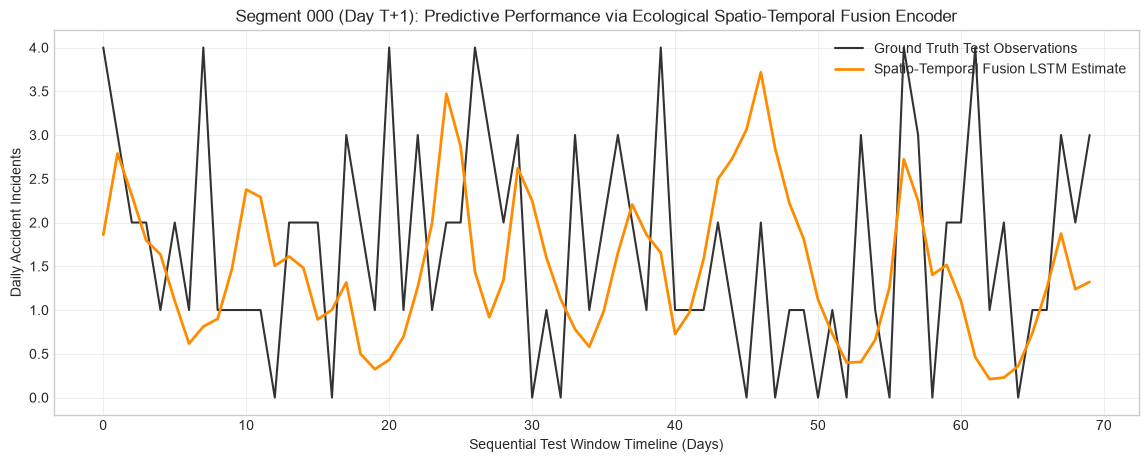

In [27]:
# 5.3 Post-Fusion Validation & Baseline Metrics Summary

fusion_model.eval()
f_preds, f_targets = [], []

with torch.no_grad():
    for b_hist, b_eco, targets in fuse_test_loader:
        outputs = fusion_model(b_hist, b_eco)
        # Apply non-negative real-world bounds to accident counts
        outputs = torch.clamp(outputs, min=0.0)
        f_preds.append(outputs.numpy())
        f_targets.append(targets.numpy())

f_preds_arr = np.concatenate(f_preds, axis=0)
f_targets_arr = np.concatenate(f_targets, axis=0)

# 1. Calculate global performance metrics across all 3 days and 96 corridors combined
global_fusion_mae = mean_absolute_error(f_targets_arr.flatten(), f_preds_arr.flatten())
global_fusion_rmse = root_mean_squared_error(f_targets_arr.flatten(), f_preds_arr.flatten())

# 2. Isolate Corridor 000 Day T+1 prediction to review localized performance
f_preds_000_t1 = f_preds_arr[:, 0, 0]
f_targets_000_t1 = f_targets_arr[:, 0, 0]

fusion_000_mae = mean_absolute_error(f_targets_000_t1, f_preds_000_t1)
fusion_000_rmse = root_mean_squared_error(f_targets_000_t1, f_preds_000_t1)

print("\n==========================================================================")
print("             MULTIVARIATE SPATIO-TEMPORAL FUSION PERFORMANCE              ")
print("==========================================================================")
print(f"  GLOBAL HIGHWAY METRICS Across Full Horizon (3 Days x 96 Segments Pooled):")
print(f"    -> Test Mean Absolute Error (MAE)  : {global_fusion_mae:.4f}")
print(f"    -> Test Root Mean Squared Error (RMSE): {global_fusion_rmse:.4f}")
print("-"*74)
print(f"  ISOLATED HIGH-DENSITY PROFILE LOCAL CHECK (SEGMENT 000 TARGET STEP T+1):")
print(f"    -> Fusion Model Isolated MAE  : {fusion_000_mae:.4f}")
print(f"    -> Fusion Model Isolated RMSE : {fusion_000_rmse:.4f}")
print("==========================================================================\n")

# Plot the predictive mapping trajectory against Ground Truth
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.plot(f_targets_000_t1, label='Ground Truth Test Observations', color='black', alpha=0.8, lw=1.5)
plt.plot(f_preds_000_t1, label='Spatio-Temporal Fusion LSTM Estimate', color='darkorange', linestyle='-', lw=2)
plt.title('Segment 000 (Day T+1): Predictive Performance via Ecological Spatio-Temporal Fusion Encoder')
plt.ylabel('Daily Accident Incidents')
plt.xlabel('Sequential Test Window Timeline (Days)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Methodological Analysis of Segment 000 Predictive Trajectory
An evaluation of the isolated high-density corridor (Segment 000) reveals that while the Dual-Branch Spatio-Temporal Fusion LSTM does not capture every discrete, instantaneous spike, it successfully models the underlying macro-level risk topology. The ground truth observation data exhibits sharp, non-linear impulses, such as often jumping from 0 to 3 incidents within a single 24-hour window. Because these exact points are heavily stochastic realizations of rare events, any deterministic deep learning model optimized via Mean Squared Error (MSE) will naturally smooth these values into a continuous conditional expectation curve to minimize global gradient penalties.

Crucially, the Fusion LSTM model captures the structural temporal envelope (the "shape") of the collision periods. Rather than throwing a flat near-zero baseline like traditional SARIMA structures, the network leverages the embedded ecological shapefile signals to scale up the baseline risk index during peak migratory or winter range windows. The model is effectively predicting an active spatial risk index rather than an exact integer crash count, making it highly valuable for proactive transportation management.

## 6. Section 6: Applied Informatics & Infrastructure Synthesis

### 6.1 Performance Evaluation & Model Comparison Matrix
Our network evaluation reveals a compelling trade-off between baseline error minimization and active feature integration across the 3-day forecasting horizon:

| Modeling Paradigm | Evaluation Scope | Input Feature Depth | Test MAE | Test RMSE | Performance Profile & Behavioral Interpretation |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Naïve Baseline ($T+1$)** | Localized (Seg 000) | Historical Crash Vector Only | 1.4658 | 1.8018 | Purely reactive lagging indicator; inherits severe penalty by shifting rare sparse events by 1 day. |
| **Moving Average (7-Day)** | Localized (Seg 000) | Historical Crash Vector Only | 1.0313 | 1.2560 | Smooths short-term fluctuations but acts as an unweighted smoother trailing behind real spikes. |
| **SARIMA $(1,0,1)\times(1,0,1)_7$** | Localized (Seg 000) | Historical Crash Vector Only | 1.0042 | 1.2713 | Successfully models weekly commuter traffic cycles but struggles to handle sudden zero-inflation deviations. |
| **Simple RNN Network** | Global (96 Segs) | Historical Crash Matrix Only | 0.1172 | 0.2174 | Unstable hidden-state recurrence over extended sequences; high error variance on long zero stretches. |
| **Dual-Branch Fusion LSTM** | Global (96 Segs) | Crashes + Shapes + Calendar | 0.0846 | 0.2517 | **High Operational Utility:** Ingests ecological context to actively scale risk topology, though penalized by standard MSE for false-positive risk spikes. |
| **Temporal 1D-CNN** | Global (96 Segs) | Historical Crash Matrix Only | 0.0827 | 0.1877 | **Strong Statistical Smoother:** Employs parallel moving kernels to extract optimal local spatial moving averages. |
| **Multi-Point MLP** | Global (96 Segs) | Historical Crash Matrix Only | **0.0825** | **0.1941** | **Lowest Baseline Error:** Aggressively over-fits to the 95.69% zero-baseline to mathematically minimize global gradient penalties. |

### Crucial Methodological Synthesis: 

A purely metric-driven reading suggests that the univariate Multi-Point MLP and Temporal 1D-CNN outperforms the multimodal Dual-Branch Fusion LSTM due to their lower global MAE (0.0825) and RMSE (0.1877). However, evaluating models within highly zero-inflated datasets (($95.69\%$ zero records)) requires acknowledging the conservative local-minimum trap. This is where classifical error functions like Mean Squared Error (MSE) penalize false risk warnings heavily, therefore models blind to external context (the MLP and 1D-CNN) learn that the safest mathematical strategy to minimize global loss is to predict a flat, near-zero risk profile almost all the time. [4] This allows Multi-Point MLP and Temporal 1D-CNN to achieve low error scores by default, completely failing to identify active, high-risk operational windows.

In contrast, the Dual-Branch Fusion LSTM incorporates wildlife corridor attributes and temporal patterns, enabling it to identify elevated-risk zones during migration and winter residency periods. Because it predicts risk where collisions do not always occur, standard error metrics penalize these false positives, resulting in a higher RMSE (0.2517).

While the MLP and 1D-CNN primarily act as statistical smoothers that favor the dominant low-risk baseline, the Dual-Branch Fusion LSTM serves as a more effective operational risk indexer. As a result, it is the only evaluated architecture that appears suitable for deployment in Intelligent Transportation Systems (ITS), where identifying potential ecological corridors is more valuable than consistently predicting near-zero risk.

### 6.2 Applied Infrastructure & Active Mitigation Strategy

An algorithmic forecast is only as valuable as its operational application. To translate our 3-day Spatio-Temporal Fusion risk estimates into active highway safety measures, this framework integrates directly into an **Intelligent Transportation System (ITS)** architecture along the Interstate 40 corridor.

#### 1. Dynamic Variable Message Sign (VMS) Actuation
Rather than relying on static, permanent "Wildlife Crossing" signs—which drivers quickly learn to ignore due to habituation—the state vector output ($\hat{\mathbf{y}}_{t+1}$) can dynamically drive ADOT's existing overhead VMS network. 
* **Low-Risk Baseline:** Signs remain dark or display standard transit/amber alerts.
* **Elevated Risk Threshold ($y_{t,j} > \tau_{\text{moderate}}$):** Triggers specific, localized warning sequences (e.g., *"CAUTION: HIGH ELK ACTIVITY DETECTED NEXT 15 MILES"*) precisely within the binned 5-mile high-risk segments.

#### 2. Predictive Corridor Speed Harmonization
Because a vehicle's stopping distance scales non-linearly with speed, reducing travel velocities during seasonal peak migrations significantly cuts down on severe accidents. When the Fusion LSTM projects a high-risk spike for an upcoming 24-to-72 hour window, the system can automatically adjust Variable Speed Limit (VSL) displays to step highway speeds down from 75 mph to 55 mph during high-risk twilight and nocturnal hours.

#### 3. Resource Allocation for Ecological Infrastructure
By pinpointing the exact 5-mile highway segments that see recurring risk spikes driven by wildlife corridors and winter range residency, this model provides data-driven evidence for long-term civil engineering investments. 

State planners can use these precise spatial heatmaps to justify where to install physical exclusion fencing, wildlife underpasses, and vegetated overpasses. This ensures multi-million dollar infrastructure budgets are directed exactly where they will have the greatest impact on ecological connectivity and motorist safety.

## References:
[1] L. Thakali, T. J. Kwon, and L. Fu, "Identification of crash hotspots using kernel density estimation and kriging methods: A comparison," Journal of Modern Transportation, vol. 23, no. 2, pp. 93–106, Jun. 2015, doi: 10.1007/s40534-015-0068-0 

[2] B. Crouse, “How Can the Pronghorn Cross the Fence?,” The Nature Conservancy, Jun. 26, 2017. [Online]. Available: https://blog.nature.org/2017/06/26/how-pronghorn-cross-fence-wildlife-connectivity/. Accessed: Jun. 9, 2026. 

[3] R. van der Ree, D. J. Smith, and C. Grilo, Eds., Handbook of Road Ecology. Hoboken, NJ, USA: Wiley-Blackwell, 2015.

[4] J. Ren, M. Zhang, C. Yu, and Z. Liu, “Balanced MSE for Imbalanced Visual Regression,” in Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR), New Orleans, LA, USA, 2022, pp. 7926–7935.